# L09 · NB 02 — Words to vectors

> *Before we use a pretrained model, let's build the intuition for what a vector representation of text actually means.*

In this notebook we will:

1. Encode words and documents as **one-hot vectors** — see why this fails for meaning
2. Move to **bag-of-words** vectors — see why this still fails for synonyms
3. Build a **tiny learned embedding** from word co-occurrence — see meaning start to emerge
4. Visualise the embedding in 2D — see semantically related words cluster

The point: by the time you see a pretrained `SentenceTransformer` in NB 03, you should know exactly what mathematical object it's producing and why.

## 1 · Setup

In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)
# Load data — local file if present (VS Code), else fetch from GitHub (works in Colab).
import os
_LOCAL = 'data/northstar_catalogue.csv'
_URL = 'https://raw.githubusercontent.com/flexfengfeng/6m-data-3.9-Natural-Language-Processing/main/notebooks/data/northstar_catalogue.csv'
df = pd.read_csv(_LOCAL if os.path.exists(_LOCAL) else _URL)
print(f"Catalogue: {len(df)} products")

Catalogue: 76 products


## 2 · One-hot encoding — the naive baseline

Build a vocabulary from all words in the catalogue. Assign each word a unique index. A word becomes a vector of zeros with a single 1.

In [2]:
def tokens(text):
    return re.findall(r'\w+', text.lower())

# Build vocabulary from BOTH name and description
vocab_counter = Counter()
for _, row in df.iterrows():
    vocab_counter.update(tokens(row['name'] + ' ' + row['description']))

VOCAB = sorted(vocab_counter.keys())
WORD_TO_IDX = {w: i for i, w in enumerate(VOCAB)}
V = len(VOCAB)
print(f"Vocabulary size: {V}")

# One-hot encode a few words
def onehot(word):
    v = np.zeros(V, dtype=np.float32)
    if word in WORD_TO_IDX:
        v[WORD_TO_IDX[word]] = 1.0
    return v

for w in ['frock', 'dress', 'gown', 'sundress', 'spaceship']:
    v = onehot(w)
    print(f"  {w!r:12s} -> vector of {v.shape}, sum={v.sum():.0f}, nonzero at index {np.argmax(v) if v.sum() > 0 else 'NONE'}")

Vocabulary size: 552
  'frock'      -> vector of (552,), sum=1, nonzero at index 188
  'dress'      -> vector of (552,), sum=1, nonzero at index 140
  'gown'       -> vector of (552,), sum=1, nonzero at index 197
  'sundress'   -> vector of (552,), sum=1, nonzero at index 462
  'spaceship'  -> vector of (552,), sum=0, nonzero at index NONE


## 3 · The equidistance problem

Compute cosine similarity between several pairs of one-hot vectors. *Every pair of distinct words has cosine 0.* That means "frock" is exactly as similar to "dress" as it is to "spaceship". Meaning is lost.

In [3]:
def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0: return 0.0
    return float(np.dot(a, b) / (na * nb))

pairs = [('frock', 'dress'), ('frock', 'gown'), ('frock', 'spaceship'), ('dress', 'dress')]
for a, b in pairs:
    sim = cosine(onehot(a), onehot(b))
    print(f"  cosine({a!r}, {b!r}) = {sim:.3f}")

  cosine('frock', 'dress') = 0.000
  cosine('frock', 'gown') = 0.000
  cosine('frock', 'spaceship') = 0.000
  cosine('dress', 'dress') = 1.000


Three different word pairs, three identical scores. The model has no notion of meaning.

## 4 · Bag-of-words (a small step up)

Represent an entire DOCUMENT as a vector of word *counts* — one count per vocab word. Two documents talking about the same topic with the same words will be close in this space.

In [4]:
def bag_of_words(text):
    v = np.zeros(V, dtype=np.float32)
    for w in tokens(text):
        if w in WORD_TO_IDX:
            v[WORD_TO_IDX[w]] += 1
    return v

# Embed all product descriptions
DESCRIPTIONS = (df['name'] + ' ' + df['description']).tolist()
bow_vecs = np.vstack([bag_of_words(d) for d in DESCRIPTIONS])
print(f"Bag-of-words matrix shape: {bow_vecs.shape}  (products × vocab)")
print(f"Density: {(bow_vecs > 0).mean():.2%} (most entries are zero — this is a SPARSE representation)")

Bag-of-words matrix shape: (76, 552)  (products × vocab)
Density: 2.11% (most entries are zero — this is a SPARSE representation)


### Now test bag-of-words as a search engine

In [5]:
def bow_search(query, top=5):
    q = bag_of_words(query)
    sims = np.array([cosine(q, bv) for bv in bow_vecs])
    order = np.argsort(-sims)[:top]
    return df.iloc[order].assign(score=sims[order])

print("Query: 'blue summer dress'")
print()
print(bow_search('blue summer dress')[['product_id','category','name','score']].to_string(index=False))

Query: 'blue summer dress'

product_id category                    name    score
     P0002    dress       Marina Wrap Dress 0.258199
     P0004    dress Holly Knit Jumper Dress 0.258199
     P0047 footwear Sand Espadrille Sandals 0.154303
     P0014    shirt       Frost Linen Shirt 0.154303
     P0007    dress    Sienna Bodycon Dress 0.149071


Same problem as keyword search — BoW only matches on shared content words. The Lila Floral Sundress (description: "lightweight floral frock") gets a low score because none of the **query words** appear in its description.

We need vectors that capture **meaning**, not just word presence.

## 5 · The embedding idea — co-occurrence

Here's the key insight (Firth, 1957): **words that appear in similar contexts tend to mean similar things.**

Build a co-occurrence matrix: for each word, count how often each other word appears within a small window around it across the whole corpus. Words that share many neighbours end up with similar count-vectors.

This is a toy version of Word2Vec / GloVe.

In [6]:
WINDOW = 5

def build_cooccurrence(documents, vocab, window=WINDOW):
    V = len(vocab)
    word_to_idx = {w: i for i, w in enumerate(vocab)}
    M = np.zeros((V, V), dtype=np.float32)
    for doc in documents:
        toks = tokens(doc)
        for i, w in enumerate(toks):
            if w not in word_to_idx: continue
            wi = word_to_idx[w]
            for j in range(max(0, i-window), min(len(toks), i+window+1)):
                if j == i: continue
                w2 = toks[j]
                if w2 not in word_to_idx: continue
                M[wi, word_to_idx[w2]] += 1
    return M

cooccur = build_cooccurrence(DESCRIPTIONS, VOCAB)
print(f"Co-occurrence matrix shape: {cooccur.shape}")
print(f"Density: {(cooccur > 0).mean():.2%}")

Co-occurrence matrix shape: (552, 552)
Density: 2.03%


Each ROW of `cooccur` is now a vector representing a word — but using its co-occurrence pattern, not just its identity.

### Try the cosine similarities again

In [7]:
def word_vec(word):
    if word not in WORD_TO_IDX: return None
    return cooccur[WORD_TO_IDX[word]]

pairs = [
    ('frock', 'dress'),
    ('frock', 'gown'),
    ('dress', 'sundress'),
    ('frock', 'leather'),    # unrelated
    ('frock', 'trainers'),   # unrelated
    ('cotton', 'linen'),     # similar fabric
    ('cotton', 'rubber'),    # different materials
]

print(f"{'pair':30s} {'cosine':>8s}")
print('-' * 42)
for a, b in pairs:
    va, vb = word_vec(a), word_vec(b)
    sim = cosine(va, vb) if va is not None and vb is not None else float('nan')
    print(f"  {a!r:14s} {b!r:14s}  {sim:>6.3f}")

pair                             cosine
------------------------------------------
  'frock'        'dress'          0.035
  'frock'        'gown'           0.158
  'dress'        'sundress'       0.054
  'frock'        'leather'        0.000
  'frock'        'trainers'       0.071
  'cotton'       'linen'          0.378
  'cotton'       'rubber'         0.239


**Real differentiation, but partial.** Compare these numbers to the one-hot case where every pair was exactly 0:

- *cotton ↔ linen* gets a meaningful 0.378 — both fabrics, often described with overlapping adjectives (breathable, lightweight)
- *frock ↔ gown* sits at 0.158 — both garment words, some shared context
- *frock ↔ trainers* near 0 — different categories, different vocabulary
- But *frock ↔ dress* is only 0.035 — surprisingly low!

The low frock/dress similarity is a real limitation of our toy embedding: each PRODUCT description uses **only one** of these synonyms, so they rarely co-occur. The model picks up "fabrics share context" much more easily than "synonyms share context" on a tiny corpus.

This is exactly the gap that **pretrained sentence-transformers fix** — they're trained on billions of sentences where the same idea is paraphrased many different ways. Tomorrow you'll see frock/dress jump to about **0.25** — roughly 7× this toy embedding's 0.035, and a meaningful ranking signal even though it doesn't look like a big number. (Sentence-transformer cosines live in [0.2, 0.7]; read them as ranking, not percent.)

## 6 · Visualise the embedding in 2D

Each word's co-occurrence vector lives in 1000+ dimensional space. We can't see that, but we can project it down to 2D with PCA and look at how words cluster.

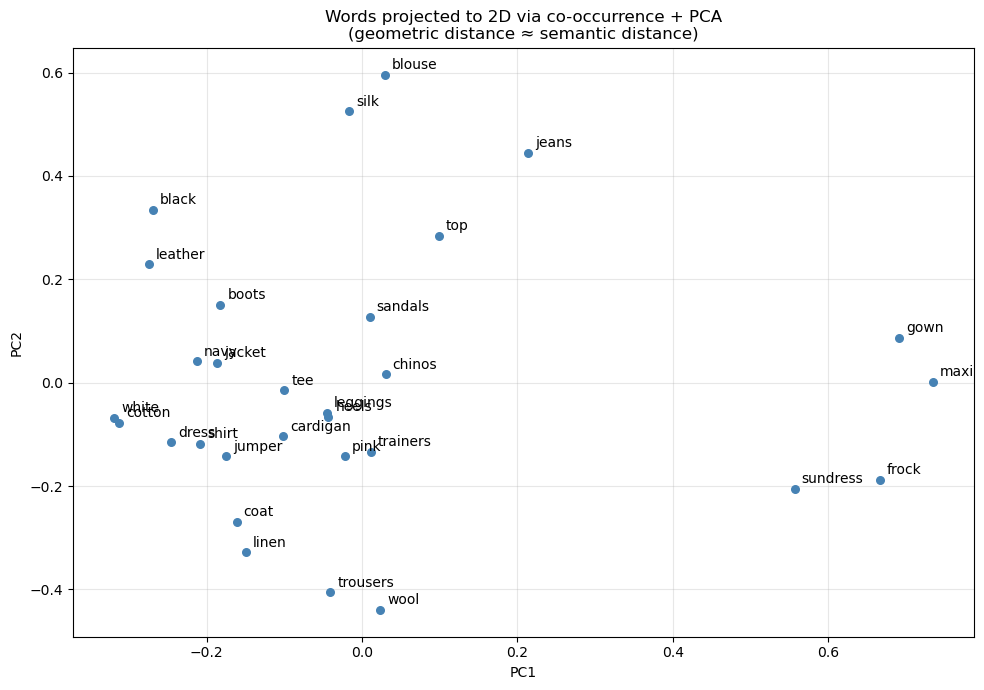

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# Pick a curated set of words from across categories
words_of_interest = [
    # dresses & related
    'dress', 'frock', 'gown', 'sundress', 'maxi',
    # tops
    'shirt', 'blouse', 'tee', 'top',
    # legs
    'trousers', 'chinos', 'leggings', 'jeans',
    # outerwear
    'coat', 'jacket', 'jumper', 'cardigan',
    # footwear
    'boots', 'trainers', 'sandals', 'heels',
    # fabrics
    'cotton', 'linen', 'wool', 'silk', 'leather',
    # colours
    'navy', 'black', 'white', 'pink',
]
# keep only those in our vocabulary
words_of_interest = [w for w in words_of_interest if w in WORD_TO_IDX]
vecs = np.vstack([word_vec(w) for w in words_of_interest])

# Normalise rows then PCA to 2D
vecs_n = normalize(vecs)
pca = PCA(n_components=2)
coords = pca.fit_transform(vecs_n)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(coords[:, 0], coords[:, 1], s=30, c='steelblue', zorder=2)
for i, w in enumerate(words_of_interest):
    ax.annotate(w, coords[i], xytext=(5, 4), textcoords='offset points', fontsize=10)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Words projected to 2D via co-occurrence + PCA\n(geometric distance ≈ semantic distance)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Look at the plot. Even with our tiny 76-document corpus you should see some partial clustering — fabric words tend to live in one region, garment words in another, footwear words mostly together. The clustering is **noisy** because the corpus is small, but the geometry is real.

In NB 03 we'll project a pretrained model's embeddings the same way and see much tighter clusters — that's what training on a billion sentences buys you.

**Key point regardless of size:** the model was never told the categories. It deduced them purely from which words tend to appear near each other. *This is meaning, expressed as geometry.* That's all an embedding is.

## 7 · Limitations of our toy embedding

Our hand-built co-occurrence vectors are real embeddings, but tiny ones. Limitations:

- **Vocabulary**: only words from THIS catalogue. Unknown words → no vector.
- **Static**: every occurrence of "bank" gets the same vector regardless of context.
- **Sparse and noisy**: 76 product descriptions is a tiny corpus. Real models train on billions of words.
- **Word-level**: we have vectors for words, not sentences. To embed a query, we'd have to average word vectors and lose word-order information.

The modern fix to all four problems is **transformer-based sentence-encoders** like the one we use in NB 03. Pretrained on >1B sentences. 30,000-token subword vocabulary. Context-aware (each word's vector depends on its neighbours). Sentence-level output.

You've now built one by hand. Tomorrow you'll plug in one that's a million times bigger.

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## E1 · Try your own word pairs

Pick five word pairs from the catalogue and compute their cosine similarity. Do the numbers match your intuition? Where does the embedding surprise you (positively or negatively)?

In [9]:
# Try any word pairs that interest you
your_pairs = [
    ('boots', 'trainers'),
    ('boots', 'sandals'),
    ('cotton', 'wool'),
    ('summer', 'winter'),
    ('cosy', 'warm'),
]
for a, b in your_pairs:
    va, vb = word_vec(a), word_vec(b)
    sim = cosine(va, vb) if va is not None and vb is not None else float('nan')
    print(f"  cosine({a!r:10s}, {b!r:10s}) = {sim:.3f}")

  cosine('boots'   , 'trainers') = 0.131
  cosine('boots'   , 'sandals' ) = 0.269
  cosine('cotton'  , 'wool'    ) = 0.147
  cosine('summer'  , 'winter'  ) = 0.188
  cosine('cosy'    , 'warm'    ) = 0.000


Notice some hits and some misses. Our embedding doesn't capture antonyms well (summer/winter often appear in similar contexts so they end up close). Real sentence-transformers handle this better, but the limitation is fundamental — the distributional hypothesis says "company you keep", and opposites often keep similar company.

## E2 · A smaller embedding via SVD

The co-occurrence rows are huge (1000+ dim). Use SVD (Singular Value Decomposition) to compress to a much smaller dense embedding — this is essentially the GloVe approach.

In [10]:
from sklearn.decomposition import TruncatedSVD

# Compress co-occurrence to 50-dim dense vectors
svd = TruncatedSVD(n_components=50, random_state=42)
dense_vecs = svd.fit_transform(cooccur)
print(f"Dense embedding shape: {dense_vecs.shape}  (vocab × 50)")
print(f"Variance explained by top 50 components: {svd.explained_variance_ratio_.sum():.2%}")

def dense_vec(word):
    if word not in WORD_TO_IDX: return None
    return dense_vecs[WORD_TO_IDX[word]]

# Same pairs as before — does compression hurt?
print("\n50-dim dense vectors:")
for a, b in [('frock','dress'), ('frock','gown'), ('cotton','linen'), ('frock','trainers')]:
    va, vb = dense_vec(a), dense_vec(b)
    print(f"  cosine({a!r:10s}, {b!r:10s}) = {cosine(va, vb):.3f}")

Dense embedding shape: (552, 50)  (vocab × 50)
Variance explained by top 50 components: 74.30%

50-dim dense vectors:
  cosine('frock'   , 'dress'   ) = 0.036
  cosine('frock'   , 'gown'    ) = 0.229
  cosine('cotton'  , 'linen'   ) = 0.402
  cosine('frock'   , 'trainers') = 0.110


Compressed embeddings preserve most of the meaning while being much faster to work with. Real models (Word2Vec, GloVe, MiniLM) output 100-768 dim vectors — never the full vocabulary size. Dense + low-dim is the modern default.